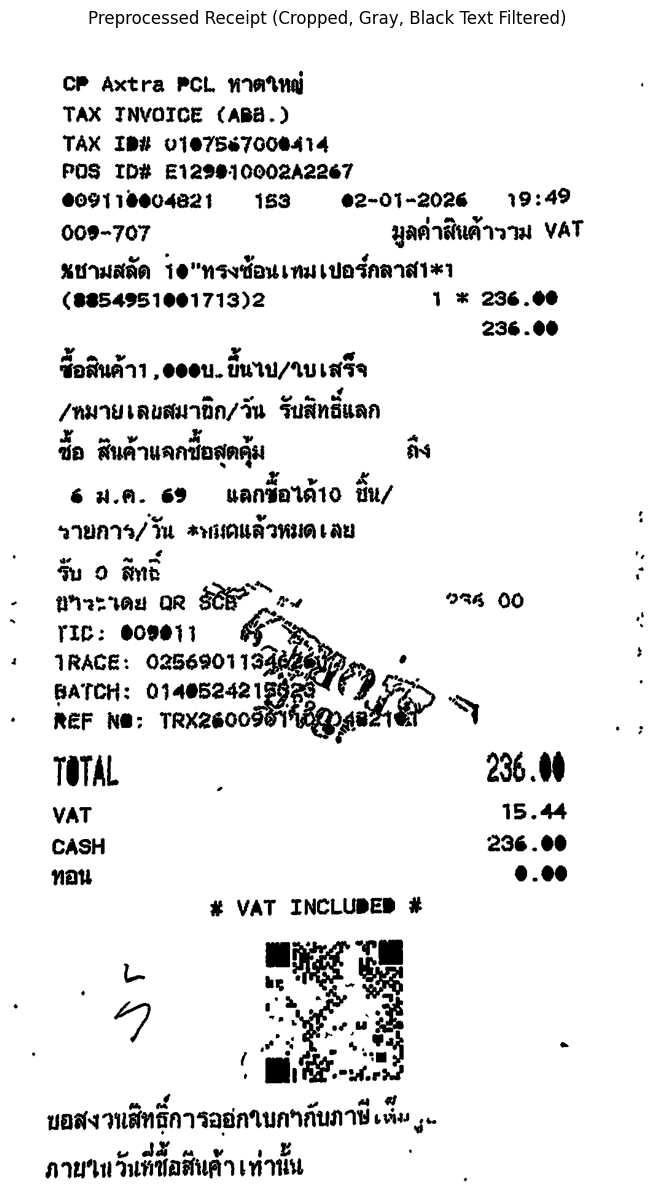

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_receipt(image_path):
    """
    ฟังก์ชันสำหรับประมวลผลภาพใบเสร็จก่อนทำ OCR (ตัดขอบ, Grayscale, กรองแต่อักษรดำ)
    เพื่อใช้แสดงผลใน Jupyter Notebook
    """
    # 1. โหลดภาพต้นฉบับ
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    # 2. การตัดขอบภาพภาพแบบอัตโนมัติ (Automatic Cropping)
    # แปลง Grayscale และ Blur เพื่อหา contours
    gray_full = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred_full = cv2.GaussianBlur(gray_full, (7, 7), 0)
    # ใช้ Otsu's Thresholding เพื่อหาขอบใบเสร็จที่ชัดเจน
    _, thresh_crop = cv2.threshold(blurred_full, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # หา contours ทั้งหมด
    contours, _ = cv2.findContours(thresh_crop, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # ตัดขอบตาม bounding box ของ contour ที่ใหญ่ที่สุด
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        # ตรวจสอบว่า contour ที่ใหญ่ที่สุดมีพื้นที่เพียงพอ (ป้องกันกรณีจับ noise แทน)
        if w > 0.1 * img.shape[1] and h > 0.1 * img.shape[0]:
            cropped_img = img[y:y+h, x:x+w]
        else:
            cropped_img = img # ถ้าไม่มั่นใจ ให้ใช้ภาพเดิม
    else:
        cropped_img = img # ถ้าไม่เจอ contours เลย ให้ใช้ภาพเดิม

    # 3. การกรองตัวอักษรดำบนภาพที่ตัดแล้ว (Black Text Filtering on Cropped Image)
    # แปลง Grayscale ของภาพที่ตัดแล้ว
    gray_cropped = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2GRAY)
    # Blur เล็กน้อยเพื่อลด noise จากแสตมป์แดง
    blurred_final = cv2.GaussianBlur(gray_cropped, (5, 5), 0)
    # ใช้ Adaptive Threshold เพื่อเน้นเฉพาะตัวอักษรสีเข้ม (ตัวอักษรดำ)
    thresh_final = cv2.adaptiveThreshold(
        blurred_final, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 4 # ปรับ blockSize และ C ตามต้องการ
    )
    
    # 4. การกรองพื้นที่ที่ไม่ใช่ตัวอักษรออก (Contour Filtering)
    # หา contours ของ thresh_final
    contours_final, _ = cv2.findContours(thresh_final, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    # สร้างภาพพื้นหลังสีขาวใหม่ที่มีขนาดเท่ากับ thresh_final
    final_img_clean = np.ones_like(thresh_final) * 255
    
    # กรอง contours ตามขนาดและอัตราส่วนภาพเพื่อวาดเฉพาะอักษรดำลงไปใหม่
    min_w, min_h = 2, 5      # ขนาดขั้นต่ำ
    max_w, max_h = 70, 100   # ขนาดสูงสุด (ปรับตามขนาดตัวอักษรจริงของคุณ)
    min_aspect_ratio = 0.1   # อัตราส่วนความกว้าง/ความสูงขั้นต่ำ
    max_aspect_ratio = 4.0   # อัตราส่วนสูงสุด

    for cnt in contours_final:
        x_t, y_t, w_t, h_t = cv2.boundingRect(cnt)
        aspect_ratio = float(w_t) / h_t
        
        # กรองขนาดและอัตราส่วน
        if (min_w < w_t < max_w and min_h < h_t < max_h and 
            min_aspect_ratio < aspect_ratio < max_aspect_ratio):
            # วาดเฉพาะ contour ที่ผ่านการกรองลงบนภาพใหม่เป็นสีดำ (0)
            cv2.drawContours(final_img_clean, [cnt], -1, (0), -1) 
    
    return final_img_clean

# --- ใช้เส้นทางไฟล์รูปภาพจริงๆ ของคุณ ---
# ตัวอย่าง:
# image_path = '/Users/faiijaran/Desktop/project/photo_for_test/1.jpeg' 
# หากรูปภาพอยู่ในโฟลเดอร์เดียวกับ Notebook ก็ใช้ชื่อไฟล์ได้เลย
image_path = '/Users/faiijaran/Desktop/project/photo_for_test/11.jpeg' # ปรับเส้นทางตามจริง

# ประมวลผลภาพ
processed_image = preprocess_receipt(image_path)

# แสดงผลใน Jupyter Notebook
if processed_image is not None:
    plt.figure(figsize=(15, 15)) # ปรับขนาดการแสดงผลตามต้องการ
    plt.imshow(processed_image, cmap='gray')
    plt.title("Preprocessed Receipt (Cropped, Gray, Black Text Filtered)")
    plt.axis("off") # ปิดแกน
    plt.show()
else:
    print("ไม่สามารถโหลดรูปภาพได้")

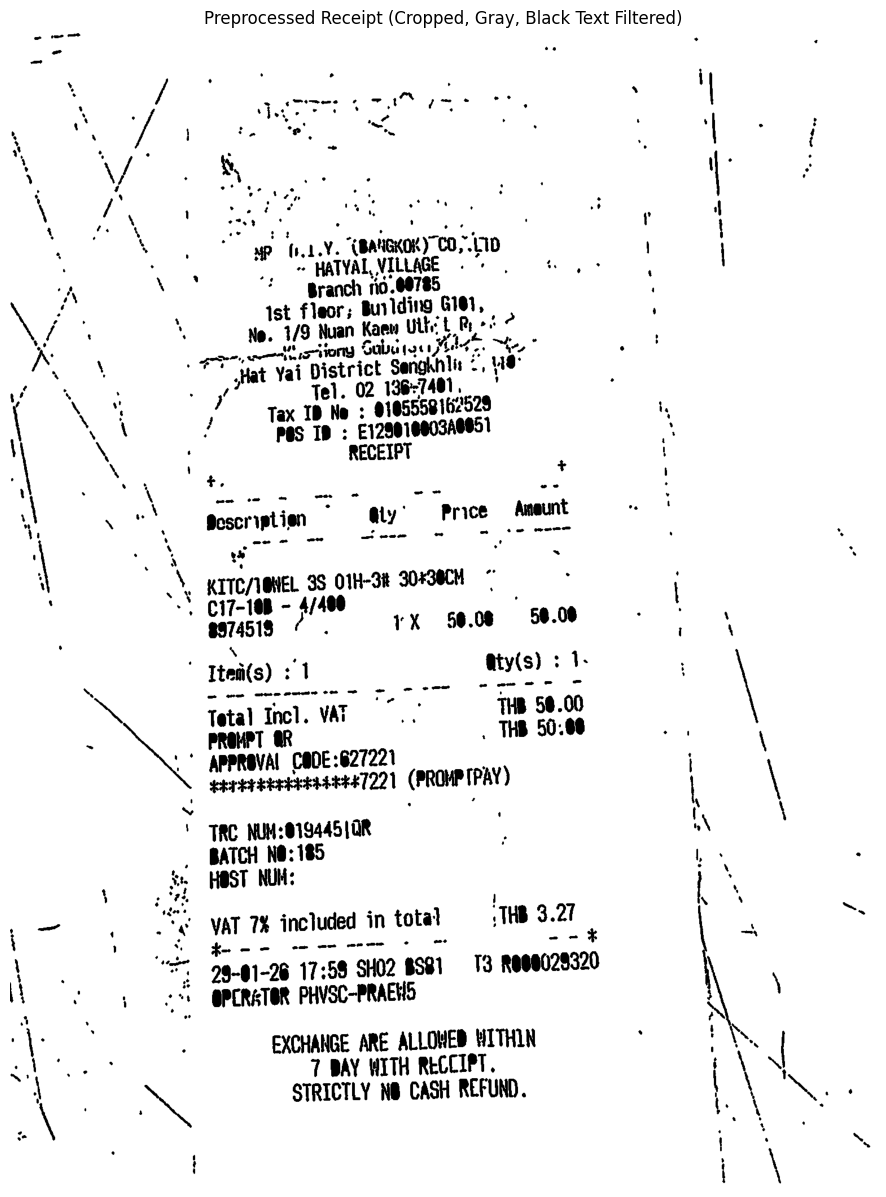

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_receipt(image_path):
    """
    ฟังก์ชันสำหรับประมวลผลภาพใบเสร็จก่อนทำ OCR (ตัดขอบ, Grayscale, กรองแต่อักษรดำ)
    เพื่อใช้แสดงผลใน Jupyter Notebook
    """
    # 1. โหลดภาพต้นฉบับ
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    # 2. การตัดขอบภาพภาพแบบอัตโนมัติ (Automatic Cropping)
    # แปลง Grayscale และ Blur เพื่อหา contours
    gray_full = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred_full = cv2.GaussianBlur(gray_full, (7, 7), 0)
    # ใช้ Otsu's Thresholding เพื่อหาขอบใบเสร็จที่ชัดเจน
    _, thresh_crop = cv2.threshold(blurred_full, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # หา contours ทั้งหมด
    contours, _ = cv2.findContours(thresh_crop, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # ตัดขอบตาม bounding box ของ contour ที่ใหญ่ที่สุด
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        # ตรวจสอบว่า contour ที่ใหญ่ที่สุดมีพื้นที่เพียงพอ (ป้องกันกรณีจับ noise แทน)
        if w > 0.1 * img.shape[1] and h > 0.1 * img.shape[0]:
            cropped_img = img[y:y+h, x:x+w]
        else:
            cropped_img = img # ถ้าไม่มั่นใจ ให้ใช้ภาพเดิม
    else:
        cropped_img = img # ถ้าไม่เจอ contours เลย ให้ใช้ภาพเดิม

    # 3. การกรองตัวอักษรดำบนภาพที่ตัดแล้ว (Black Text Filtering on Cropped Image)
    # แปลง Grayscale ของภาพที่ตัดแล้ว
    gray_cropped = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2GRAY)
    # Blur เล็กน้อยเพื่อลด noise จากแสตมป์แดง
    blurred_final = cv2.GaussianBlur(gray_cropped, (5, 5), 0)
    # ใช้ Adaptive Threshold เพื่อเน้นเฉพาะตัวอักษรสีเข้ม (ตัวอักษรดำ)
    thresh_final = cv2.adaptiveThreshold(
        blurred_final, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 4 # ปรับ blockSize และ C ตามต้องการ
    )
    
    # 4. การกรองพื้นที่ที่ไม่ใช่ตัวอักษรออก (Contour Filtering)
    # หา contours ของ thresh_final
    contours_final, _ = cv2.findContours(thresh_final, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    # สร้างภาพพื้นหลังสีขาวใหม่ที่มีขนาดเท่ากับ thresh_final
    final_img_clean = np.ones_like(thresh_final) * 255
    
    # กรอง contours ตามขนาดและอัตราส่วนภาพเพื่อวาดเฉพาะอักษรดำลงไปใหม่
    min_w, min_h = 2, 5      # ขนาดขั้นต่ำ
    max_w, max_h = 70, 100   # ขนาดสูงสุด (ปรับตามขนาดตัวอักษรจริงของคุณ)
    min_aspect_ratio = 0.1   # อัตราส่วนความกว้าง/ความสูงขั้นต่ำ
    max_aspect_ratio = 4.0   # อัตราส่วนสูงสุด

    for cnt in contours_final:
        x_t, y_t, w_t, h_t = cv2.boundingRect(cnt)
        aspect_ratio = float(w_t) / h_t
        
        # กรองขนาดและอัตราส่วน
        if (min_w < w_t < max_w and min_h < h_t < max_h and 
            min_aspect_ratio < aspect_ratio < max_aspect_ratio):
            # วาดเฉพาะ contour ที่ผ่านการกรองลงบนภาพใหม่เป็นสีดำ (0)
            cv2.drawContours(final_img_clean, [cnt], -1, (0), -1) 
    
    return final_img_clean

# --- ใช้เส้นทางไฟล์รูปภาพจริงๆ ของคุณ ---
# ตัวอย่าง:
# image_path = '/Users/faiijaran/Desktop/project/photo_for_test/1.jpeg' 
# หากรูปภาพอยู่ในโฟลเดอร์เดียวกับ Notebook ก็ใช้ชื่อไฟล์ได้เลย
image_path = '/Users/faiijaran/Desktop/project/photo_for_test/2.jpeg' # ปรับเส้นทางตามจริง

# ประมวลผลภาพ
processed_image = preprocess_receipt(image_path)

# แสดงผลใน Jupyter Notebook
if processed_image is not None:
    plt.figure(figsize=(15, 15)) # ปรับขนาดการแสดงผลตามต้องการ
    plt.imshow(processed_image, cmap='gray')
    plt.title("Preprocessed Receipt (Cropped, Gray, Black Text Filtered)")
    plt.axis("off") # ปิดแกน
    plt.show()
else:
    print("ไม่สามารถโหลดรูปภาพได้")

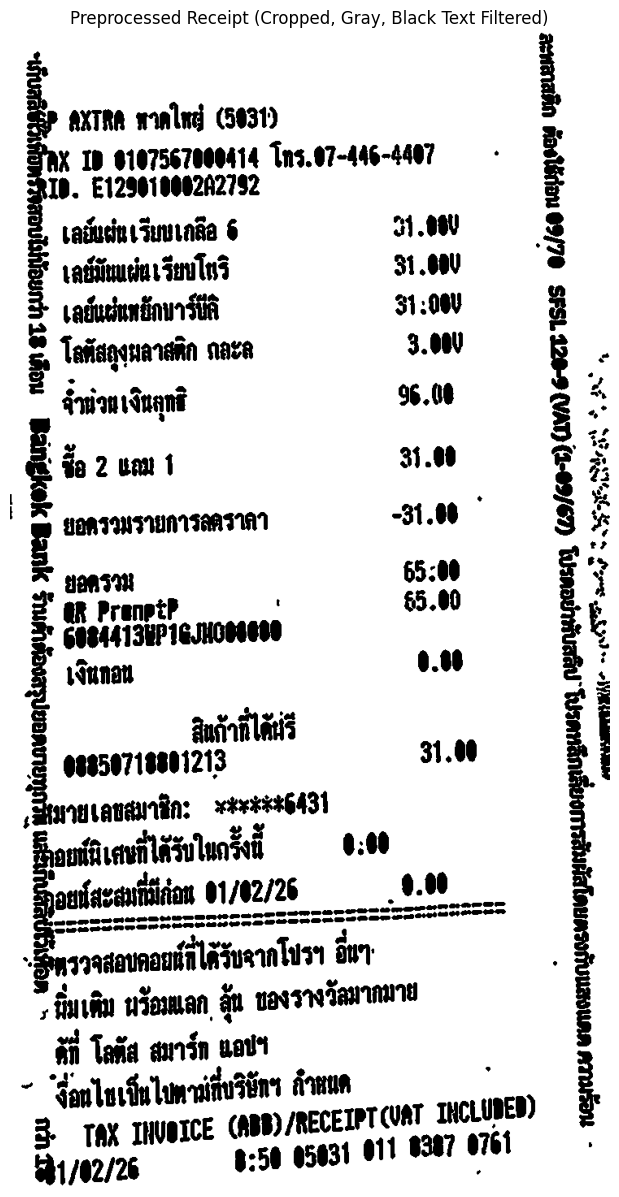

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_receipt(image_path):
    """
    ฟังก์ชันสำหรับประมวลผลภาพใบเสร็จก่อนทำ OCR (ตัดขอบ, Grayscale, กรองแต่อักษรดำ)
    เพื่อใช้แสดงผลใน Jupyter Notebook
    """
    # 1. โหลดภาพต้นฉบับ
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    # 2. การตัดขอบภาพภาพแบบอัตโนมัติ (Automatic Cropping)
    # แปลง Grayscale และ Blur เพื่อหา contours
    gray_full = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred_full = cv2.GaussianBlur(gray_full, (7, 7), 0)
    # ใช้ Otsu's Thresholding เพื่อหาขอบใบเสร็จที่ชัดเจน
    _, thresh_crop = cv2.threshold(blurred_full, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # หา contours ทั้งหมด
    contours, _ = cv2.findContours(thresh_crop, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # ตัดขอบตาม bounding box ของ contour ที่ใหญ่ที่สุด
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        # ตรวจสอบว่า contour ที่ใหญ่ที่สุดมีพื้นที่เพียงพอ (ป้องกันกรณีจับ noise แทน)
        if w > 0.1 * img.shape[1] and h > 0.1 * img.shape[0]:
            cropped_img = img[y:y+h, x:x+w]
        else:
            cropped_img = img # ถ้าไม่มั่นใจ ให้ใช้ภาพเดิม
    else:
        cropped_img = img # ถ้าไม่เจอ contours เลย ให้ใช้ภาพเดิม

    # 3. การกรองตัวอักษรดำบนภาพที่ตัดแล้ว (Black Text Filtering on Cropped Image)
    # แปลง Grayscale ของภาพที่ตัดแล้ว
    gray_cropped = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2GRAY)
    # Blur เล็กน้อยเพื่อลด noise จากแสตมป์แดง
    blurred_final = cv2.GaussianBlur(gray_cropped, (5, 5), 0)
    # ใช้ Adaptive Threshold เพื่อเน้นเฉพาะตัวอักษรสีเข้ม (ตัวอักษรดำ)
    thresh_final = cv2.adaptiveThreshold(
        blurred_final, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 4 # ปรับ blockSize และ C ตามต้องการ
    )
    
    # 4. การกรองพื้นที่ที่ไม่ใช่ตัวอักษรออก (Contour Filtering)
    # หา contours ของ thresh_final
    contours_final, _ = cv2.findContours(thresh_final, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    # สร้างภาพพื้นหลังสีขาวใหม่ที่มีขนาดเท่ากับ thresh_final
    final_img_clean = np.ones_like(thresh_final) * 255
    
    # กรอง contours ตามขนาดและอัตราส่วนภาพเพื่อวาดเฉพาะอักษรดำลงไปใหม่
    min_w, min_h = 2, 5      # ขนาดขั้นต่ำ
    max_w, max_h = 70, 100   # ขนาดสูงสุด (ปรับตามขนาดตัวอักษรจริงของคุณ)
    min_aspect_ratio = 0.1   # อัตราส่วนความกว้าง/ความสูงขั้นต่ำ
    max_aspect_ratio = 4.0   # อัตราส่วนสูงสุด

    for cnt in contours_final:
        x_t, y_t, w_t, h_t = cv2.boundingRect(cnt)
        aspect_ratio = float(w_t) / h_t
        
        # กรองขนาดและอัตราส่วน
        if (min_w < w_t < max_w and min_h < h_t < max_h and 
            min_aspect_ratio < aspect_ratio < max_aspect_ratio):
            # วาดเฉพาะ contour ที่ผ่านการกรองลงบนภาพใหม่เป็นสีดำ (0)
            cv2.drawContours(final_img_clean, [cnt], -1, (0), -1) 
    
    return final_img_clean

# --- ใช้เส้นทางไฟล์รูปภาพจริงๆ ของคุณ ---
# ตัวอย่าง:
# image_path = '/Users/faiijaran/Desktop/project/photo_for_test/1.jpeg' 
# หากรูปภาพอยู่ในโฟลเดอร์เดียวกับ Notebook ก็ใช้ชื่อไฟล์ได้เลย
image_path = '/Users/faiijaran/Desktop/project/photo_for_test/12.jpeg' # ปรับเส้นทางตามจริง

# ประมวลผลภาพ
processed_image = preprocess_receipt(image_path)

# แสดงผลใน Jupyter Notebook
if processed_image is not None:
    plt.figure(figsize=(15, 15)) # ปรับขนาดการแสดงผลตามต้องการ
    plt.imshow(processed_image, cmap='gray')
    plt.title("Preprocessed Receipt (Cropped, Gray, Black Text Filtered)")
    plt.axis("off") # ปิดแกน
    plt.show()
else:
    print("ไม่สามารถโหลดรูปภาพได้")